# Machine Learning-based Force Fields

Link of the original tutorial: [Link](https://github.com/molet/MLFF_tutorial/blob/main/MLFF.ipynb)

## 1. Introduction
In this tutorial, we demonstrate how we can derive and use machine learning (ML) based force fields for a simple system: *alanine dipeptied in implicit solvent*

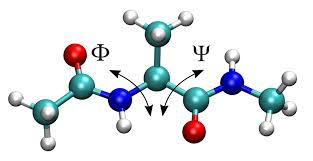

In [1]:
# Show the image of the molecule. Please change the path incase if you want to visualize yourown molecule
from IPython.display import Image
Image(filename='/Users/dipteshgayen/Documents/Projects/1_Project_AI_for_MD/ML_FF/Images/alanine_dipeptide.jpeg', width=500)

The following steps will be carried out:

1. Construct the system.
2. Perform biased molecular dynamics simuations using a classical force field ([ff14Bonlysc](https://pubs.acs.org/doi/full/10.1021/ja5032776)) based potential to obtain samples. The bias is is provided by [metadynamics](https://pmc.ncbi.nlm.nih.gov/articles/PMC130499/), which is an adaptive potential of mean force technique.
3. Compute energy and atomic forces of collected configurations using a more expensive semiempirical potential [PM6](https://pubs.acs.org/doi/10.1021/ct9000922)
4. Fit the PM6 potential energy surface by [Gaussian process regression](#Gaussianprocess) and nerual network (NN).
5. Perform molecular dynamics simulations on ML-based potential energy surface.
6. Compute the free energy surface [Ramachandran plot](https://en.wikipedia.org/wiki/Ramachandran_plot) on ML-based potential.

[**What is Gaussian process regression?**](#Gaussianprocess)

Gausian process (GP) is a supervised learning method used to solve regression and probabilistic classificatin problems. It has the term "Gaussian" in its name as each Gaussian process can be seen as an infinite dimensional generalation of multivariate Gaussian distributions.

* Univarite: One variable.
* Multivariate: Multiple variables at the same time.
  * Example: x = (x1, x2, x3)
  * A multivariate Gaussian describes uncertainty over a vector of numbers.

GP for regression problem is known as Gaussian process regression (GPR).

GPR is a non-parmeteric Bayesian apporach for inference. Instead of inferring a distribution over the parameters of a parametric function, Guassian prcoess can be used to infere a distribution over the function of interest directly. A Gaussian process defines a prior function (what you believe before seeing data), which is converted to a posterior function (what you believe after seeing data) after having observed some values from the prior distribution. Output of the GPR is a probability distribution.

A Gaussina process is a random process where any point x in the real domain is assigned a random variable $f(x)$ and where the join distribution of a finite number of these variables $p(f(x_1), ..., f(x_n))$ follows a Gaussian distribution:

$$ p(f|X) \sim N(f|\mu, K) \tag{1}$$

where $f=(f(x_1), .., f(x_N)$, $\mu=(m(x_1), .., m(x_N)$, and $K_{ij} = k(x_i, x_j)$.

In Equation (1), $m$ is the *mean* function, where people typically use $m(x)=0$ as GPs are flexible enought to model the mean even if it's set to an arbitary value at the beginning. $k$ is a positive definite function referred to as the *kernel* function or *covariance* function.

## 2. Required softwares

* For creating the system and initial coordinates we use the [AmberTools](https://ambermd.org/AmberTools.php) package. This package is also used for providing the ff14SBonlysc force field and the PM6 semiempricial potenial.

* Unbiased and biased molecular dynamics simulations as well as analyses of trajectoreis are performed within the [Atomistic Simulation Environment](https://ase-lib.org/) (ASE).

* Interacrive view of the structures and trajectories is provided by [nglview](https://nglviewer.org/nglview/latest/).

* Finally, for [automatic differentiation](https://en.wikipedia.org/wiki/Automatic_differentiation) and constuction of the GPR and NN models, we use PyTorch.  

## 3. Software Installation

All computations are performed using **Python 3** within a dedicated **conda environment**.  
The environment includes JupyterLab, AmberTools, and all required scientific and machine-learning packages.

### 3.1. Conda environment

A fully reproducible conda environment is provided via an `environment.yml` file available in the GitHub repository:

> **Repository:** <ADD GITHUB LINK HERE>

Create the environment from the project root:

```bash
conda env create -f environment.yml


## 4. Load packages and functions

In [2]:
!pip install "numpy<2"
# ignore warnings
import warnings
warnings.filterwarnings("ignore")

# progress bar
import tqdm

# load ase related functions
from ase import units
from ase.calculators.calculator import Calculator
from ase.calculators.amber import SANDER
from ase.io import read, write
from ase.io.trajectory import Trajectory
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.md import MolecularDynamics
from ase.md import Langevin
from ase.optimize.precon import PreconLBFGS

# load parmed and sander
from parmed.amber.readparm import Rst7, AmberParm
import sander

# load numpy
import numpy as np

# load matplot for plotting
import matplotlib.pyplot as plt

# load nglview for visualization
from nglview import show_file, show_asetraj

# load torch functions for computing derivaties and ML
import torch
import functorch as ft
import torch.autograd.functional as F


!pip install jupyterlab-indent-guides

# display youtube videos
from IPython.display import YouTubeVideo

Now, we are all set to write some code. Beautiful!!!

In [3]:
# Set the precision to double, by default it is float32. 
dt = torch.float64

## 5. Create the system using AmberTools

**Create the leap input file for alanine dipeptide (aka dialanine)**

```python
# Load the AMBER ff14SB force field (side-chain–optimized version)
source leaprc.protein.ff14SBonlysc

# Build a neutral, capped alanine peptide: ACE–ALA–NME
dialanine = sequence {ACE ALA NME}

# Set atomic radii for PB/GB implicit solvent calculations
set default PBradii mbondi3

# Write topology and coordinate files
saveamberparm dialanine dialanine.top dialanine.crd

# Exit tleap
quit
```

**What is a residue?**

In molecular simulations, a residue is a repeating stuctural unit of a larger molecule. 
* ALA -> Alanine residue
* ACE -> acetyl capping residue
* NME -> N-methylamide capping residue

In MD packages, *residue* is a topological concept, not just a biochemical one. A resideu can be:
* an amino acid
* a nucleotide
* a ligand
* a solvent molecule
* an ion


In [4]:
%%file leap.in 
source leaprc.protein.ff14SBonlysc 
dialanine = sequence {ACE ALA NME} 
set default PBradii mbondi3
saveamberparm dialanine dialanine.top dialanine.crd 
quit

Overwriting leap.in


**Run tleap to obtain topolgoy and coordinate files for the specified force field and create a pdf file as well**

In [5]:
! tleap -f leap.in > leap.log
! ambpdb -p dialanine.top -c dialanine.crd -aatm > dialanine.pdb

**Visualize the initial structure, you know the motto of a good machine learning researcher: Visualize, Visualize, and Visualize!!**

In [6]:
show_file("./dialanine.pdb")

NGLWidget()

This is called Acetyl-alanine-N-methylamide. The chemical structure of it is: **CH3-CO-NH-CH(CH3)-CO-NH-CH3**.

In *AMBER* notation: ACE-ALA-NME

## 6. Basic functions with ASE

### 6.1. Load atoms, topology, and coordinate files

In [7]:
# read the pdf file to Atoms object
atoms = read("dialanine.pdb")

In [8]:
# show the Cartesian coordinates (unit: Angstrom)
pos = atoms.get_positions()
symbols = atoms.get_chemical_symbols()
print("# Cartesian coordinates (in Angstrom)")
print(f"{'Idx':>4} {'Atom':>4} {'x':>12} {'y':>12} {'z':>12}")
for i, (sym, (x, y, z)) in enumerate(zip(symbols, pos), start=1):
    print(f"{i:4d} {sym:>4} {x:12.6f} {y:12.6f} {z:12.6f}")

# Cartesian coordinates (in Angstrom)
 Idx Atom            x            y            z
   1    H     2.000000     1.000000     0.000000
   2    C     2.000000     2.090000     0.000000
   3    H     1.486000     2.454000     0.890000
   4    H     1.486000     2.454000    -0.890000
   5    C     3.427000     2.641000     0.000000
   6    O     4.391000     1.877000     0.000000
   7    N     3.555000     3.970000     0.000000
   8    H     2.733000     4.556000     0.000000
   9    C     4.853000     4.614000     0.000000
  10    H     5.408000     4.316000     0.890000
  11    C     5.661000     4.221000    -1.232000
  12    H     5.123000     4.521000    -2.131000
  13    H     6.630000     4.719000    -1.206000
  14    H     5.809000     3.141000    -1.241000
  15    C     4.713000     6.129000     0.000000
  16    O     3.601000     6.653000     0.000000
  17    N     5.846000     6.835000     0.000000
  18    H     6.737000     6.359000     0.000000
  19    C     5.846000     8.28

In [9]:
# get the distance matrix --> distances between all atoms
distance = atoms.get_all_distances()
print(f" Shape of the distance matrix is: {distance.shape}")
print(f" Fist row of the distance matrix:\n {distance[0]}")

 Shape of the distance matrix is: (22, 22)
 Fist row of the distance matrix:
 [0.         1.09       1.78056508 1.78056508 2.17467469 2.54676461
 3.3524506  3.63076094 4.60441147 4.83760478 5.02947174 5.16640407
 6.05989249 4.5422949  5.80232798 5.87533914 6.98848632 7.15248558
 8.23701232 8.15099166 8.84836731 8.84836731]


In [10]:
# get the atomic masses 
masses = atoms.get_masses()
for i,j in zip(symbols, masses):
    print(f"Atom {i} has mass {j}")

Atom H has mass 1.008
Atom C has mass 12.011
Atom H has mass 1.008
Atom H has mass 1.008
Atom C has mass 12.011
Atom O has mass 15.999
Atom N has mass 14.007
Atom H has mass 1.008
Atom C has mass 12.011
Atom H has mass 1.008
Atom C has mass 12.011
Atom H has mass 1.008
Atom H has mass 1.008
Atom H has mass 1.008
Atom C has mass 12.011
Atom O has mass 15.999
Atom N has mass 14.007
Atom H has mass 1.008
Atom C has mass 12.011
Atom H has mass 1.008
Atom H has mass 1.008
Atom H has mass 1.008


**The ASE Atoms object** provides:
* Cartesian coordinates
* Atom ordering
* Chemical symbols

**AMBER topology file (.top)** cotnains:
* Force-field parametes
* Atom types
* Charges
* Bonded connectivity

**AMBER coordinate file (.crd or .inpcrd)** used for:
* Initial reference structure
* Atom ordering consistency

In [11]:
# now, let's read the Amber topology and coordinate files
top = AmberParm("dialanine.top")
crd = Rst7("dialanine.crd")

### 6.2. Setup an ASE calculator

In ASE, a calculator is the object that knows the physics: it takes atomic positions and returns energies, forces, stresses, etc. 

Atoms + Calculator -> Energy, Forces, Stress etc. 

Here we use AMBER's sander engine as an ASE calcultor, with a classifical force field and implicit solvent, so that ASE can ask for energies and foces.

In symbols:

$$ \text{ASE Atoms} \xrightarrow []{\text{SANDER calculator}} E(R), F $$

Generalized Born implicit solvent model means:
1. No periodic box
2. Implicit solvent
3. Continuum electrostatics

In [12]:
# Setup a SANDER calculator using generalized Born implicit solvent 
mm_options = sander.gas_input(5)

# This line constructs an ASE calcultor object that wraps AMBER's sander
calc_ff = SANDER(atoms=atoms, top=top, crd=crd, mm_options=mm_options)

# Set the Atoms object caclculator
atoms.set_calculator(calc_ff)

### 6.3 Get energy and atomic forces

**The default unit of energy in ASE is *ev* that can be convered to *Kcal/mol* by using the corresponding conversion factors.**


In [13]:
potential_energy = atoms.get_potential_energy()*units.mol/units.kcal
forces = atoms.get_forces()* units.mol / units.kcal

print(f"Potential energy: {potential_energy} Kcal/mol")
print(f"Shape of the forces : {forces.shape}")
print(f"Force on the atom {symbols[0]} is {forces[0]} Kcal/mol/Angstrom")

Potential energy: -28.284223306904 Kcal/mol
Shape of the forces : (22, 3)
Force on the atom H is [ 2.71923793  0.56504916 -0.00547658] Kcal/mol/Angstrom


### 6.4. Perform a geometry optimization

**Geometry optimiztion: LMFGS method**

What is a LMFGS method? (Further reading: [Limited-memory BFGS](https://en.wikipedia.org/wiki/Limited-memory_BFGS))

Limited-memory BFGS is an optimization algorithm. The algorithm's target problem is to minimize $f(x)$ over unconstrained values of the real-vector $x$ where $f$ is a differentiable scalar function.

`PreconLBFGS` is an ASE geometry optimizer: a preconfined version of the L-BFGS quasi-Netwon method for relaxing atomic structures. 

`PreconLBFGS` introduces a preconditioner. What is a preconditioner? A preconditioner rescales the problem so that, stiff directions or soft directions are treated more uniformly. Mathematically, instead of minimizing:
$$ E(R) $$

you minimize:

$$ E(P^{1/2}R)$$

where P is the preconditioner.

In [14]:
# Geometry optimization
opt = PreconLBFGS(atoms,
                  trajectory="geometry_optimization/geom_opt.traj", 
                  use_armijo=True, 
                  precon="ID")
opt.run(fmax=0.0001)

PreconLBFGS:   0  21:02:07       -1.226520       0.9745
PreconLBFGS:   1  21:02:07       -1.272629       0.9834
PreconLBFGS:   2  21:02:07       -1.332909       0.7023
PreconLBFGS:   3  21:02:07       -1.375669       0.7742
PreconLBFGS:   4  21:02:07       -1.393535       1.2136
PreconLBFGS:   5  21:02:07       -1.413195       0.7067
PreconLBFGS:   6  21:02:07       -1.433304       0.9102
PreconLBFGS:   7  21:02:07       -1.449865       0.8962
PreconLBFGS:   8  21:02:07       -1.460515       0.6019
PreconLBFGS:   9  21:02:07       -1.471153       0.5923
PreconLBFGS:  10  21:02:07       -1.476936       0.4301
PreconLBFGS:  11  21:02:07       -1.483894       0.4390
PreconLBFGS:  12  21:02:07       -1.488622       0.6044
PreconLBFGS:  13  21:02:07       -1.494424       0.3590
PreconLBFGS:  14  21:02:07       -1.500415       0.4023
PreconLBFGS:  15  21:02:07       -1.507630       0.3770
PreconLBFGS:  16  21:02:07       -1.516111       0.3952
PreconLBFGS:  17  21:02:07       -1.522806      

True

Let's visualize the energy (energy vs step) and (max force vs step)

In [15]:
# load the optimizatin trajectory

traj = read("geometry_optimization/geom_opt.traj", ":")
nsteps = len(traj)
print(f"Optimization steps: {nsteps}")

Optimization steps: 124


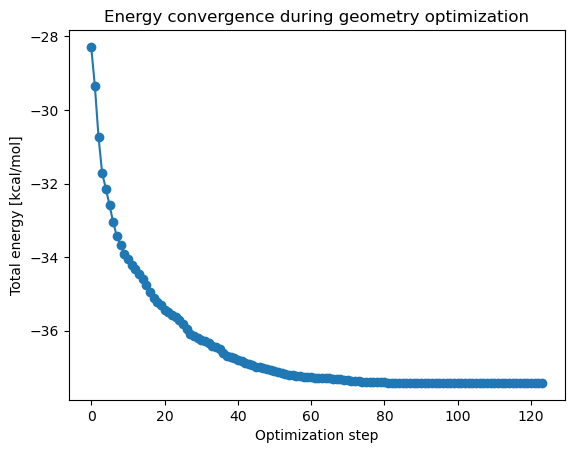

In [16]:
# Plot energy vs optimization step
energies = [atoms.get_potential_energy() * units.mol/ units.kcal for atoms in traj]
plt.figure()
plt.plot(range(len(energies)), energies, marker="o")
plt.xlabel("Optimization step")
plt.ylabel("Total energy [kcal/mol]")
plt.title("Energy convergence during geometry optimization");

In [17]:
# Plot maximum force vs step
traj_forces = [atoms.get_forces() for atoms in traj]
traj_forces = np.array(traj_forces)
traj_forces.shape 

(124, 22, 3)

`traj_forces` is a 3D array --> (#steps, #atoms, dimensions)

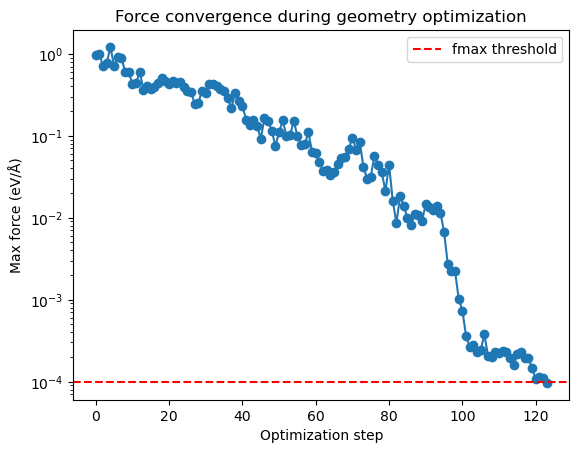

In [18]:
#maximum force vs step
max_forces = [
    np.max(np.linalg.norm(atoms.get_forces(), axis=1))
    for atoms in traj
]
plt.figure()
plt.semilogy(range(len(max_forces)), max_forces, marker="o")
plt.axhline(1e-4, color="r", linestyle="--", label="fmax threshold")
plt.xlabel("Optimization step")
plt.ylabel("Max force (eV/Å)")
plt.title("Force convergence during geometry optimization")
plt.legend()
plt.show()

In [19]:
# show the trajectory
view = show_asetraj(traj)
view


NGLWidget(max_frame=123)

## 7. Unbiased molecular dynamics simulaiton


### 7.1 Create an MD class using BAOAB scheme

BAOAB is a numerical integrator for [Langevin dynamics](https://en.wikipedia.org/wiki/Langevin_dynamics) that can model friction by solvent molecules and perturbation caused by occasional high velocity collision. Instead of simulating every solvent molecule explicitly, Langevin dynamics models their influence through friction and random thermal noise.

In Langevin dynamics, the motion of the atom is describe by two couple equations:

$$ d\mathbf{q}dt = \textbf{M}^{-1}\mathbf{p}dt$$
$$ d\mathbf{p}dt = -\nabla V(\mathbf{q})dt - \gamma \mathbf{p} dt + \sqrt{2\gamma \beta^-1} \textbf{M}^{1/2} dW $$

where,
* $q, p \in \mathbb{R}^{3N}$ are the atomic positions and momenta,
* $M \in \mathbb{R}^{3N \times 3N}$ is the diagonal mass matrix,
* $\gamma >0 $ is the friciton coefficient,
* $\beta = \frac{1}{k_{B}T}$ is the inverse temperature
* $dW$ represent random noise form the heat bath (a Wiener process).


**Why Langevin dynamics?**

This type of dynamics naturally samples the canonical (NVT) ensemble, meaning that over time the system explores configurations according to the Boltzmann distribution:

$$ p(q,p) \propto \exp^{-\beta H(q,p)} $$

where $H(q,p)$ is the total energy (Hamilotonian) of the system. 


In [20]:
class BAOAB(MolecularDynamics):
    """ Langevin (constant N, V, T) molecular dynamics using BAOAB scheme. 
    Usage: BAOAB(atoms, timestep, T, friction, nscm)

    Inputs:
        atoms -- The list of atoms.
        timestep -- The time step.
        T -- The desired temprature in energy units 
        friction -- A friction coefficient in fs^-1
        nscm -- frequency of removing translation and rotational COM motion in number of steps.

        This dynamics accesses the atoms using Cartesian coordinates"""
    def __init__(self, atoms, timestep, T=None, friction=None, *, nscm=0, rndseed=None, 
                 trajectory=None, logfile=None, loginterval=1, dtype = torch.float64):
        
        
        
        # Initialize the parent MolecularDynamics
        MolecularDynamics.__init__(self, atoms, timestep, trajectory, logfile, loginterval)

        self.dtype = dtype

        # Thermal energy k_B T (ASE units)
        self.kT = torch.tensor(units.kB * T, dtype = self.dtype)

        # Friction coefficient
        self.frict = torch.tensor(friction / units.fs, dtype=self.dtype)

        # Frequency for removing center-of-mass motion
        self.nscm = nscm
        
        if rndseed is not None:
            torch.manual_seed(rndseed)

        
        

        # Half time step 
        self.halfdt = torch.tensor(0.5 * self.dt, dtype=self.dtype)

        # Atomic masses (1D array)
        self.m = torch.tensor(atoms.get_masses(), dtype=self.dtype)

        # Total mass (used for COM motion removal)
        self.sumM = torch.sum(self.m)

        # Mass matrix expanded to shape (N_atoms, 3)
        self.M = torch.tensor(
            atoms.get_masses().repeat(3).reshape(-1, 3),
            dtype = self.dtype
        )
        
        # Inverse mass matrix (element-wise)
        self.invM = 1.0 / self.M

        # precompute (delta/2) * 1/M, used in position updates 
        self.halfdt_invM = self.halfdt * self.invM

        # Exponential damping factor for the Ornstein-Uhlenbeck (B) step 
        self.epsilon = torch.exp(-self.dt * self.frict)

        # Nosie prefactor for the stochastic momentum update
        self.chi2_halfM = (
            torch.sqrt(self.kT * (1.0 - self.epsilon * self.epsilon))
            * torch.sqrt(self.M)
        )
        # Force array placeholder (same shape as positions)
        self.f = torch.zeros(atoms.get_positions().shape,
                            dtype=self.dtype)

    def step(self, force=None):
        """
        Perform one BAOAB Langevin integration step
        BAOAB splitting:
        O_half : p <- p + (dt/2) * F(q)
        A_half : q <- q + (dt/2) * M^{-1}p
        B_full : p <- exp(-gamma*dt) p + sqrt(kT * (1-exp(-2*gamma*dt))*M) * R
        A_half : q <- q + (dt/2) * M^{-1}p
        O_half : p <- p + (dt/2) * F(q_new)
        """

        if self.nsteps == 0:
            f = torch.tensor(self.atoms.get_forces(), dtype=self.dtype)
        else:
            f = self.f

        # Read moment p and positions q from ASE 
        p = torch.tensor(self.atoms.get_momenta(), dtype=self.dtype) # shape (N, 3) 
        q = torch.tensor(self.atoms.get_positions(), dtype=self.dtype) # shape (N, 3)

        # Draw Gaussian random numbers for the stochastic B step
        r = torch.randn(q.shape, dtype=self.dtype)

        # O (half step) : momentum kick by conservative forces
        p = p + self.halfdt * f

        # A (half step): drift positions using current momenta
        q = q + self.halfdt_invM * p

        # B (full step): Ornstein-Uhlenbeck thermostat in momenta
        # epsilon = exp(-gamma * dt)
        # sigma * sqrt(M) = sqrt(kT * (1-exp(-2*\gamma*dt)))
        p = self.epsilon * p + self.chi2_halfM * r

        # A (half step)
        q = q + self.halfdt_invM * p

        # Push updated coordinates back into ASE
        self.atoms.set_positions(q.detach().numpy())

        # Compute new forces at the updated positions
        f = torch.tensor(self.atoms.get_forces(), dtype=self.dtype)

        # O (half step) : final momentum kich using new forces
        p = p + self.halfdt * f

        # cache forces for next stpe to avoid recomputing at the start
        self.f = f

        # push updated momenta back into ASE
        self.atoms.set_momenta(p.detach().numpy())

        # Remove center-of-mass translation/rotation every nscm steps
        if self.nscm != 0:
            if (self.nsteps + 1) % self.nscm == 0 or self.nsteps == 0:
                self.remove_trans_rot()

        # Return froces as numpy array
        return f.detach().numpy()

    def todict(self):
        return 0


    def remove_trans_rot(self):
        """"
        Remove center-of-mass (COM) translational and rotational motion from the system. 

        The idea:
        1) Compute COM linear velocity v_com from total momentum.
        2) Compute COM angular velocity omega_com from angular momentum
        3) Subtract rigid-body contributions from each atom's momentum:
            p_i <- p_i - m_i * (v_com + omega_com x r_i)
            where r_i is position relative to the COM
        """
        # COM position 
        qcom = torch.tensor(self.atoms.get_center_of_mass(), dtype=self.dtype)

        
        # Current atomic momenta p_i (shape Nx3)
        p = torch.tensor(self.atoms.get_momenta(), dtype=self.dtype)

        # Total momentum P = \sum_i p_i
        trans_mom_com = p.sum(axis=0)

        # COM velocity v_com = P / M_total
        trans_vel_com = trans_mom_com / self.sumM

        # Translational kinetic energy: (1/2) * M_total * |v_com|^2
        trans_kin = 0.5 * self.sumM * torch.dot(trans_vel_com, trans_vel_com)

        # Total angular momentum about COM
        ang_mom_com = torch.tensor(self.atoms.get_angular_momentum(), dtype=self.dtype)

        # Relative coordinates
        rq = torch.tensor(self.atoms.get_positions(), dtype=self.dtype) - qcom 

        # Build the rigid-body inertial tensor I about COM:
        # I_xx = \sum_{i} m_i (y_i**2 + z_i**2)
        # I_yy =
        # I_zz = 
        # ...

        rq2 = rq ** 2 
        inertia_tensor = torch.zeros((3, 3), dtype=self.dtype)

        inertia_tensor[0, 0] = torch.sum(self.m * (rq2[:, 1] + rq2[:, 2]))
        inertia_tensor[1, 1] = torch.sum(self.m * (rq2[:, 0] + rq2[:, 2]))
        inertia_tensor[2, 2] = torch.sum(self.m * (rq2[:, 0] + rq2[:, 1]))

        inertia_tensor[0, 1] = -torch.sum(self.m * rq[:, 0] * rq[:, 1])
        inertia_tensor[0, 2] = -torch.sum(self.m * rq[:, 0] * rq[:, 2])
        inertia_tensor[1, 2] = -torch.sum(self.m * rq[:, 1] * rq[:, 2])

        inertia_tensor[1, 0] = inertia_tensor[0, 1]
        inertia_tensor[2, 0] = inertia_tensor[0, 2]
        inertia_tensor[2, 1] = inertia_tensor[1, 2]

        # Angular momentum, L = I * omega
        ang_vel_com = torch.linalg.solve(inertia_tensor, ang_mom_com)

        # Rotational kinetic energy
        rot_kin = 0.5 * torch.dot(ang_vel_com , ang_mom_com)

        # Build omega repeated to N x 3 so cross(omega, r_i) works per atom
        omega = ang_vel_com.repeat(self.atoms.get_number_of_atoms()).reshape(rq.shape)
        
        # Rigid-body velocity at atom i: v_com + omega x r_i
        rigid_vel = trans_vel_com + torch.cross(omega, rq, dim=1)

        # subract rigid momentum: m_i * rigid_vel
        p = p - self.M * rigid_vel

        self.atoms.set_momenta(p)
        

        

### 7.2 Setup an MD simulation

In [21]:
# initialize velocites according to Maxwell-Boltzmann distribution
MaxwellBoltzmannDistribution(atoms=atoms, temperature_K=300)

# Setup an unbiased molecular dynamics simulaiton
dyn_unbiased = BAOAB(atoms=atoms, timestep=0.5*units.fs, T=300, friction=0.05, nscm=1000, rndseed=314159265)


### 7.3 Monitoring the molecule dynamics, collective variables and trajectory

In [22]:
class MonitorMD:
    def __init__(self, atoms, dyn):
        self.atoms = atoms
        self.dyn = dyn

    def write(self):
        pot = self.atoms.calc.get_property("energy") # potential eneregy
        kin = self.atoms.get_kinetic_energy() # kinetic energy
        etot = pot + kin
        temp = kin / (1.5 * units.kB) / len(self.atoms) 
        print(
            f"step = {self.dyn.nsteps:7d}"
            f" | E_pot = {pot * units.mol / units.kcal:6.3f}"
            f" | E_kin = {kin * units.mol / units.kcal:6.3f}"
            f" | E_tot = {etot * units.mol / units.kcal:6.3f}"
            f" | T = {temp:5.1f}"
        ) 

monitor_md_unbiased = MonitorMD(atoms, dyn_unbiased)

### 7.4 Let's calculate the distance between two atoms

In [23]:
class Distance(torch.nn.Module):
    """"
    Distance between two atoms. 

    This module compute the Eucledian distance |r_i - r_j| give cartesian coordinates q.

    Inputs:
        atomi, atomj: int
    """
    def __init__(self, atomi, atomj): 
        super().__init__() # Always call super().__init__ when subclassing nn.Module
        self.atomi = atomi
        self.atomj = atomj

    def forward(self, q):
        """
        Inputs:
        q: torch.tensor, shape (N_atoms, 3)

        Returns:
        torch.Tensor
            Scalar distance between atom i and atom j
        """
        rij = q[self.atomi, :] - q[self.atomj, :]

        return torch.linalg.norm(rij)
        

### 7.5. Angle between three atoms

In [24]:
class Angle(torch.nn.Module):
    """"
    Angle formed by three atoms: i-j-k

    The angle is define at the central atom j, between vectors:
    r_ij = r_i - r_j
    r_kj = r_k - r_j

    """
    def __init__(self, atomi, atomj, atomk, cos=False):
        super().__init__()
        self.atomi = atomi
        self.atomj = atomj
        self.atomk = atomk
        self.cos = cos

    def forward(self, q):
        """"
        Inputs
            q: torch.Tensor, shape (N_atoms, 3)

        Returns:
            Angle (radians) or cos(angle), depending on "self.cos"

        """
        rij = q[self.atomi, :] - q[self.atomj, :]
        rkj = q[self.atomk, :] - q[self.atomj, :]

        if self.cos:
            return torch.dot(rij, rkj) / (torch.linalg.norm(rij) * torch.linalg.norm(rkj))
        else:
            return torch.acos(torch.dot(rij, rkj) / (torch.linalg.norm(rij), torch.linalg.norm(rkj)))
    

### 7.6 Dihedral angle between for four atoms

In [25]:
class Dihedral(torch.nn.Module):
    def __init__(self, atomi, atomj, atomk, atoml, tan=False):
        super(Dihedral, self).__init__()
        self.atomi = atomi
        self.atomj = atomj
        self.atomk = atomk
        self.atoml = atoml
        self.tan = tan
    
    def forward(self, q):
        rij = q[self.atomi, :] - q[self.atomj, :]
        rkj = q[self.atomk, :] - q[self.atomj, :]
        rlk = q[self.atoml, :] - q[self.atomk, :]
    
        ekj = rkj / torch.linalg.norm(rkj)
        v = rij - torch.dot(rij, ekj) * ekj
        w = rlk - torch.dot(rlk, ekj) * ekj
        
        if self.tan:
            return torch.dot(torch.cross(ekj, v), w) / torch.dot(v, w)
        else:
            return torch.atan2(torch.dot(torch.cross(ekj, v), w), torch.dot(v, w))

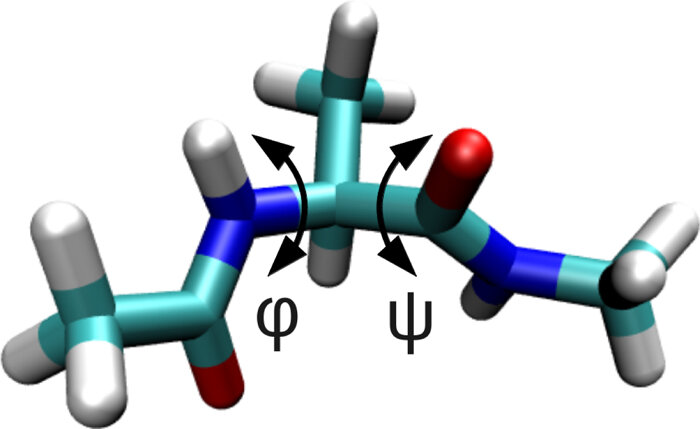

In [26]:
Image(filename="/Users/dipteshgayen/Documents/Projects/1_Project_AI_for_MD/ML_FF/Images/dihedral_dipeptide.jpg", width=500)

In [27]:
# define dihedral phi
phi = Dihedral(5, 7, 9, 15)

# define dihedral psi
psi = Dihedral(7, 9, 15, 17)

# list of CVs
cvs = [phi, psi]

**Positions as PyTorch tensor**

In [28]:
q = torch.tensor(atoms.get_positions())

**Value of $\varphi$ and $\psi$**

In [29]:
phi_value = phi.forward(q)
psi_value = psi.forward(q)

**Gradient of $\varphi$ with respect to the positions**

In [30]:
grad_phi = ft.jacrev(phi)
grad_phi(q)

tensor([[ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [-0.1933,  0.1543,  0.3384],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.2149, -0.0758, -0.3741],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.1895, -0.1165, -0.3310],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [-0.2112,  0.0380,  0.3667],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000]], dtype=torch.float64)

**Hessian of $\psi$ with respect to the positions**

In [31]:
hessian_phi = ft.hessian(phi)
hessian_phi(q).shape

torch.Size([22, 3, 22, 3])

**Monitoring the CVs**

In [32]:

class MonitorCVs:
    def __init__(self, atoms, cvs):
        self.atoms = atoms
        self.cvs = cvs
        self.values = []
        
    def append(self):
        self.values.append([cv(torch.tensor(self.atoms.get_positions(), dtype=torch.float64)).detach().numpy() for cv in self.cvs])
        
    def get_values(self):
        return np.array(self.values)
        
monitor_cvs_unbiased = MonitorCVs(atoms, cvs)

**Saving the trajectory**

In [33]:
traj_unbiased = Trajectory("/Users/dipteshgayen/Documents/Projects/1_Project_AI_for_MD/ML_FF/trajectory_unbiased/md.traj", "w", atoms=atoms)

**Attach monitoring objects**

In [34]:
dyn_unbiased.attach(monitor_md_unbiased.write, interval=1000)
dyn_unbiased.attach(monitor_cvs_unbiased.append, interval=10)
dyn_unbiased.attach(traj_unbiased.write, interval=1000)

In [35]:
nstep = 100000

dyn_unbiased.run(nstep)

step =       0 | E_pot = -37.422 | E_kin = 19.289 | E_tot = -18.133 | T = 294.1
step =    1000 | E_pot = -17.221 | E_kin = 13.325 | E_tot = -3.896 | T = 203.2
step =    2000 | E_pot = -19.755 | E_kin = 14.831 | E_tot = -4.924 | T = 226.2
step =    3000 | E_pot = -25.513 | E_kin = 16.876 | E_tot = -8.638 | T = 257.3
step =    4000 | E_pot = -15.465 | E_kin = 13.657 | E_tot = -1.808 | T = 208.3
step =    5000 | E_pot = -20.293 | E_kin = 20.680 | E_tot =  0.388 | T = 315.4
step =    6000 | E_pot = -19.214 | E_kin = 18.784 | E_tot = -0.430 | T = 286.4
step =    7000 | E_pot = -15.309 | E_kin = 24.576 | E_tot =  9.267 | T = 374.8
step =    8000 | E_pot = -21.972 | E_kin = 12.518 | E_tot = -9.454 | T = 190.9
step =    9000 | E_pot = -19.622 | E_kin = 20.459 | E_tot =  0.837 | T = 312.0
step =   10000 | E_pot = -15.559 | E_kin = 18.035 | E_tot =  2.476 | T = 275.0
step =   11000 | E_pot = -19.340 | E_kin = 18.098 | E_tot = -1.243 | T = 276.0
step =   12000 | E_pot = -22.298 | E_kin = 17.096 |

### 7.7 Visualize

In [36]:
traj = Trajectory("/Users/dipteshgayen/Documents/Projects/1_Project_AI_for_MD/ML_FF/trajectory_unbiased/md.traj")
view = show_asetraj(traj)
#view.player.parameters = dict(delay=20)
view

NGLWidget(max_frame=100)

''

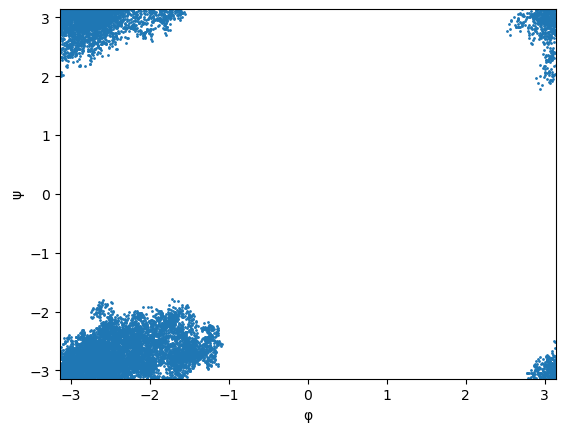

In [39]:
cvs_unibaised = monitor_cvs_unbiased.get_values()

plt.scatter(cvs_unibaised[:, 0], cvs_unibaised[:, 1], s=1)
plt.xlim(-np.pi, np.pi)
plt.ylim(-np.pi, np.pi)
plt.xlabel('φ')
plt.ylabel('ψ')
;

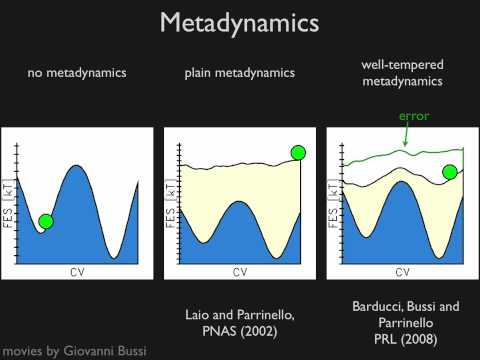

In [38]:
YouTubeVideo("IzEBpQ0c8TA", width=600, height=450, allow_autoplay=True)